# 💘 Speed Dating Analysis — Tinder Case Study
### Comprendre les facteurs d'attraction : pourquoi certaines personnes obtiennent-elles un second rendez-vous ?

---
**Données** : Columbia Business School Speed Dating Experiment, 2002-2004  
**Objectif** : Identifier les leviers réels de l'attraction au-delà des préférences déclarées  
**Auteur** : Data Analyst — Projet Tinder Marketing

---


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# ── Thème visuel ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.color':      '#aaaacc',
    'ytick.color':      '#aaaacc',
    'text.color':       '#e0e0ff',
    'grid.color':       '#333355',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#555577',
})

PINK   = '#ff4d6d'
BLUE   = '#4d79ff'
GOLD   = '#ffd166'
TEAL   = '#06d6a0'
PURPLE = '#9b5de5'
COLORS = [PINK, BLUE, GOLD, TEAL, PURPLE, '#f77f00']

print("✅ Imports OK — thème activé")


✅ Imports OK — thème activé


## 1. Chargement & Nettoyage des données

In [6]:
df = pd.read_csv('Speed+Dating+Data.csv', encoding='latin1')

print(f"Shape brut : {df.shape}")
print(f"Participants uniques : {df['iid'].nunique()}")
print(f"Vagues (waves)      : {df['wave'].nunique()}")
print(f"Taux de match global : {df['match'].mean():.1%}")




Shape brut : (8378, 195)
Participants uniques : 551
Vagues (waves)      : 21
Taux de match global : 16.5%


In [9]:
# ── Colonnes clés pour l'analyse ────────────────────────────────────────────
ATTRS       = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
ATTRS_FR    = ['Attractivité', 'Sincérité', 'Intelligence', 'Fun', 'Ambition', 'Intérêts communs']
PREFS_TIME1 = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
SELF_RATE   = ['attr3_1', 'sinc3_1', 'fun3_1', 'intel3_1', 'amb3_1']
SELF_FR     = ['Attractivité', 'Sincérité', 'Fun', 'Intelligence', 'Ambition']

# Filtre propre : lignes avec match + attributs complets
data = df[['iid','gender','match','dec','dec_o','wave','order',
           'samerace','int_corr','age','age_o',
           'like','like_o','prob','prob_o'] + ATTRS + PREFS_TIME1 + SELF_RATE].copy()

data = data.dropna(subset=ATTRS + ['match'])
print(f"Lignes après nettoyage : {len(data):,}  ({len(data)/len(df)*100:.0f}% du jeu initial)")
print(f"Taux de match sur données propres : {data['match'].mean():.1%}")


Lignes après nettoyage : 7,040  (84% du jeu initial)
Taux de match sur données propres : 17.2%


## 2. Statistiques descriptives

In [33]:
data.describe()


,iid,gender,match,dec,dec_o,wave,order,samerace,int_corr,age,...,sinc1_1,intel1_1,fun1_1,amb1_1,shar1_1,attr3_1,sinc3_1,fun3_1,intel3_1,amb3_1
count,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,7040.000000,6908.000000,6961.000000,...,6970.000000,6970.000000,6960.000000,6954.000000,6932.000000,6944.000000,6944.000000,6944.000000,6944.000000,6944.000000
mean,284.342756,0.508949,0.172301,0.431250,0.432670,11.370313,8.804972,0.392472,0.194855,26.237035,...,17.369835,20.330763,17.433454,10.755463,11.765284,7.105703,8.297811,7.738479,8.434332,7.625864
std,159.459105,0.499955,0.377669,0.495286,0.495481,6.028883,5.430249,0.488335,0.304963,3.470791,...,7.017758,6.729375,6.120932,6.057695,6.252111,1.401035,1.437954,1.558180,1.083710,1.808568
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,-0.830000,18.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.000000,2.000000,3.000000,2.000000
25%,155.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,0.000000,-0.020000,24.000000,...,15.000000,17.310000,15.000000,5.000000,10.000000,6.000000,8.000000,7.000000,8.000000,7.000000
50%,280.000000,1.000000,0.000000,0.000000,0.000000,11.000000,8.000000,0.000000,0.210000,26.000000,...,18.000000,20.000000,18.000000,10.000000,10.260000,7.000000,8.000000,8.000000,8.000000,8.000000
75%,413.000000,1.000000,0.000000,1.000000,1.000000,15.000000,13.000000,1.000000,0.430000,28.000000,...,20.000000,23.810000,20.000000,15.000000,15.415000,8.000000,9.000000,9.000000,9.000000,9.000000
max,552.000000,1.000000,1.000000,1.000000,1.000000,21.000000,22.000000,1.000000,0.910000,55.000000,...,47.000000,50.000000,50.000000,53.000000,30.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [34]:
print("=== Notes moyennes données aux partenaires (tous rendez-vous) ===")
desc = data[ATTRS].agg(['mean','std','min','max']).T
desc.index = ATTRS_FR
desc.columns = ['Moyenne', 'Écart-type', 'Min', 'Max']
print(desc.round(2).to_string())

print("\n=== Taux de match par genre ===")
gender_match = data.groupby('gender')['match'].agg(['mean','sum','count'])
gender_match.index = ['Femmes','Hommes']
gender_match.columns = ['Taux match', 'Nb matchs', 'Nb rendez-vous']
gender_match['Taux match'] = gender_match['Taux match'].map('{:.1%}'.format)
print(gender_match.to_string())


=== Notes moyennes données aux partenaires (tous rendez-vous) ===
                  Moyenne  Écart-type  Min   Max
Attractivité         6.19        1.95  0.0  10.0
Sincérité            7.16        1.74  0.0  10.0
Intelligence         7.36        1.56  0.0  10.0
Fun                  6.40        1.96  0.0  10.0
Ambition             6.76        1.80  0.0  10.0
Intérêts communs     5.46        2.15  0.0  10.0

=== Taux de match par genre ===
       Taux match  Nb matchs  Nb rendez-vous
Femmes      17.1%        591            3457
Hommes      17.4%        622            3583


In [35]:
# Tableau croisé genre × note
print("\n=== Notes moyennes par genre ===")
gender_stats = data.groupby('gender')[ATTRS].mean().T
gender_stats.index = ATTRS_FR
gender_stats.columns = ['Femmes', 'Hommes']
print(gender_stats.round(2))

# Tableau croisé match × note
print("\n=== Notes moyennes selon issue ===")
match_stats = data.groupby('match')[ATTRS].mean().T
match_stats.index = ATTRS_FR
match_stats.columns = ['Non-match', 'Match']
print(match_stats.round(2))


=== Notes moyennes par genre ===
                  Femmes  Hommes
Attractivité        5.93    6.44
Sincérité           7.09    7.23
Intelligence        7.45    7.27
Fun                 6.28    6.51
Ambition            6.94    6.59
Intérêts communs    5.40    5.53

=== Notes moyennes selon issue ===
                  Non-match  Match
Attractivité           5.96   7.33
Sincérité              7.03   7.80
Intelligence           7.23   7.95
Fun                    6.15   7.60
Ambition               6.64   7.33
Intérêts communs       5.20   6.75


- Comment les notes sont-elles distribueés en général (Après le speed dating) ?  

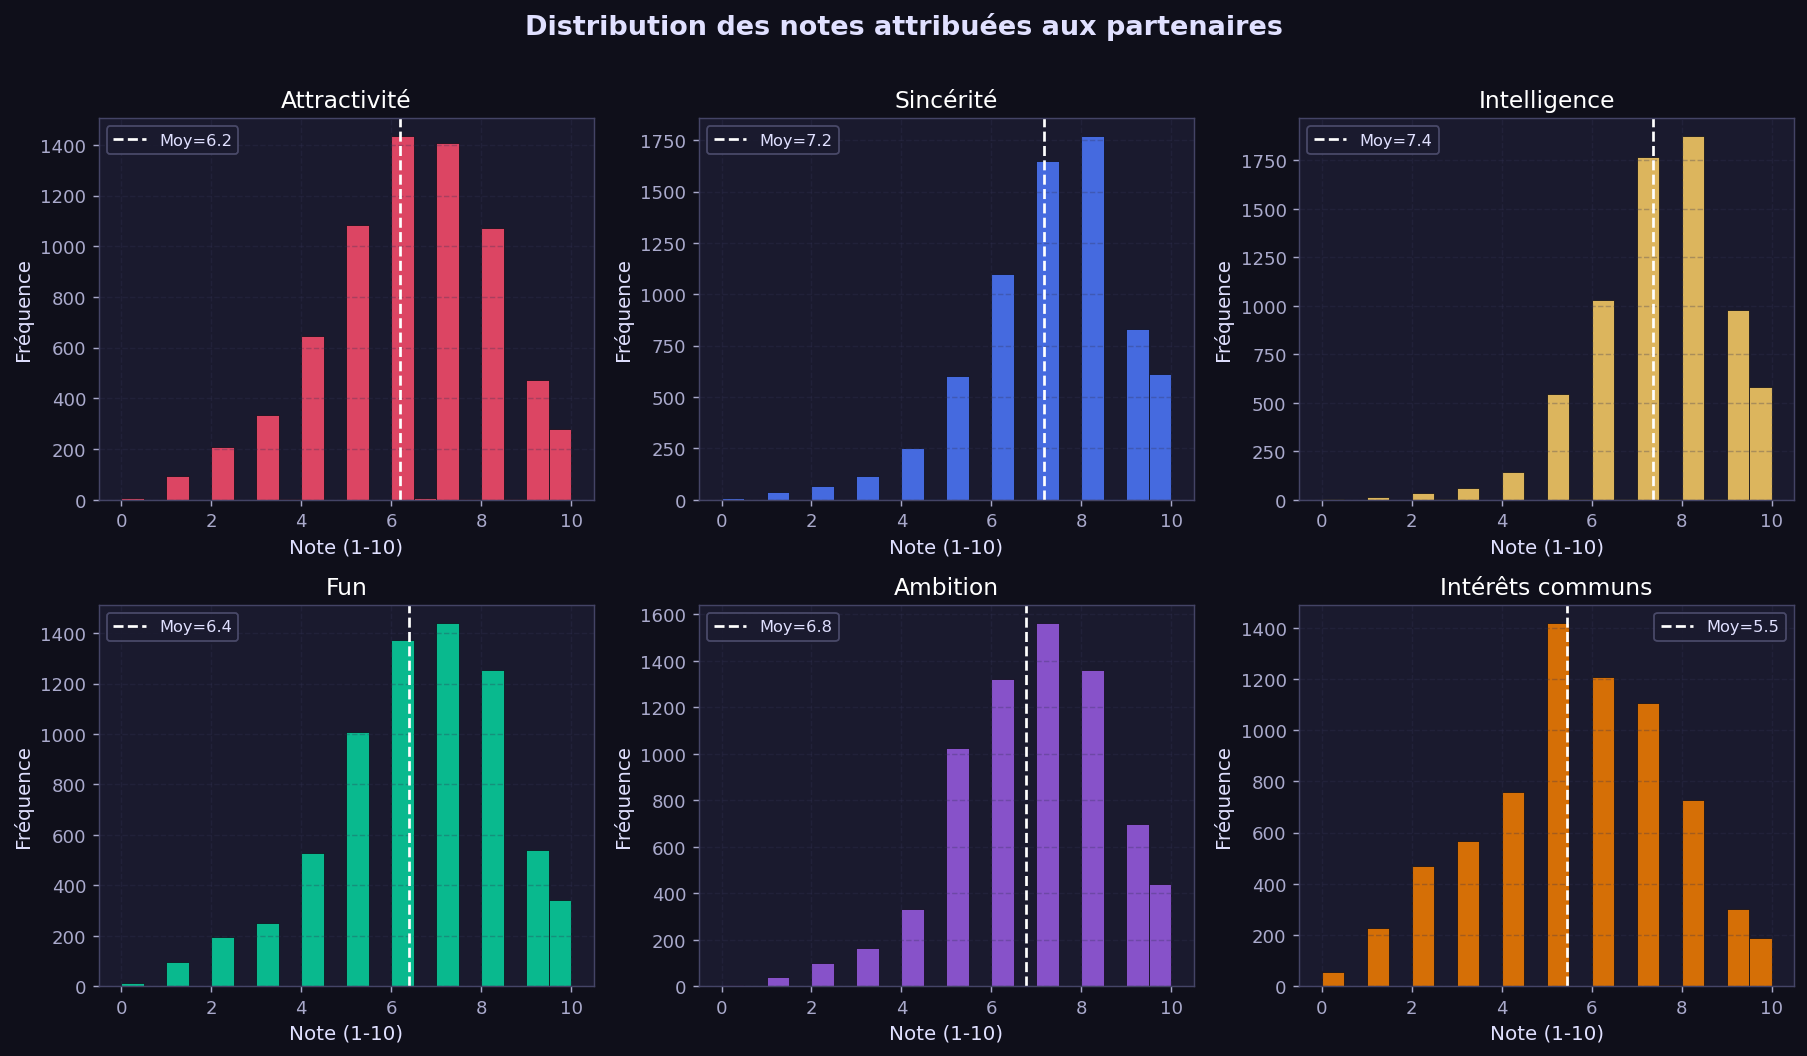

In [36]:
# ── Figure 1 : Distribution des notes par attribut ──────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution des notes attribuées aux partenaires', fontsize=15, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes.flat, ATTRS, ATTRS_FR, COLORS):
    data1 = data[col].dropna()
    ax.hist(data1, bins=20, color=color, alpha=0.85, edgecolor='#0f0f1a', linewidth=0.5)
    ax.axvline(data1.mean(), color='white', linestyle='--', linewidth=1.5, label=f'Moy={data1.mean():.1f}')
    ax.set_title(label)
    ax.set_xlabel('Note (1-10)')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_distribution_notes.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()



Analyse des resultats de la figure 1 : 
- l'intelligence et la sincérité sont les dimensions les mieux évaluées, ce sont probablement des qualités très valorisées
- l'attractivité physique n'arrive qu'en 5 eme position, soit les participants sont indulgents, soit l'attractivité perçue n'est pas le critère dominant dans ce contexte court.
- les interets communs sont les plus bas, logique car en 4mn il est difficile d'évaluer précisément les centres d'interet partagés.

/!\ : On ne sait pas si les notes varient selon genre ou l'issue(match ou non)

- Hommes et femmes notent-ils différemment ? 

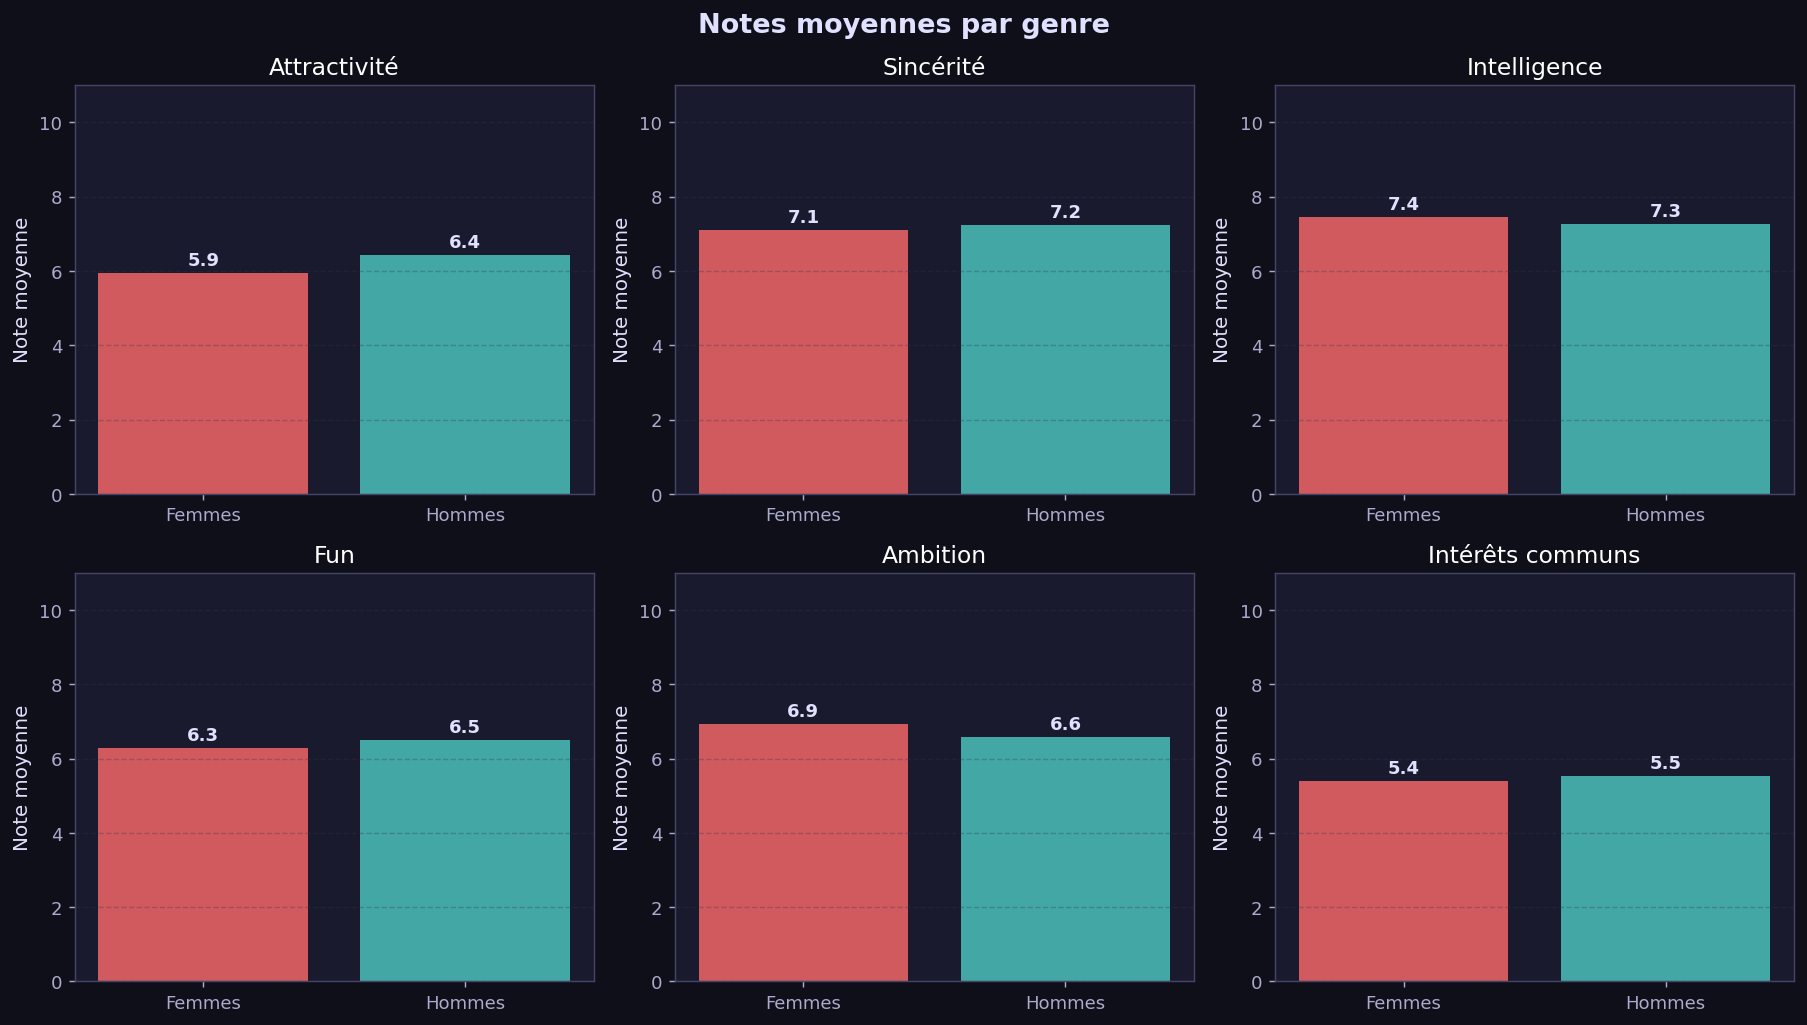

In [37]:
# Figure 2 : Notes par genre ___________________________________ 

fig2, axes2 = plt.subplots(2, 3, figsize=(14, 8))
fig2.suptitle('Notes moyennes par genre', fontsize=15, fontweight='bold')

for ax, col, label in zip(axes2.flat, ATTRS, ATTRS_FR):
    data_f = data[data['gender']==0][col].dropna()  # femmes
    data_m = data[data['gender']==1][col].dropna()  # hommes
   
    means = [data_f.mean(), data_m.mean()]
    bars = ax.bar(['Femmes', 'Hommes'], means,
                  color=['#ff6b6b', '#4ecdc4'], alpha=0.8)
   
    # Afficher la valeur sur chaque barre
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
   
    ax.set_title(label)
    ax.set_ylabel('Note moyenne')
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Analyse des resultats de la figure 2 : 
- Hommes notent l'attractivité des femmes 0.5 point plus haut que les femmes, ils sont plus sensibles généreux à l'apparence physique.
- Femmes notent l'ambition des hommes 0.3 point plus haut, les femmes valorisent légérement plus le statut/ambition chez un partenaire.
- intelligence : quasi égalité les deux genres jugent comparablement
- sincèrité et intérets communs : écarts infimes (<0.2 point).

L'analyse des notes par genre révèle que les hommes sur-notent significativement l'attractivité physique (+0.5), tandis que les femmes sur-notent modérément l'ambition (+0.3).Sur les autres critères (intelligence, sincérité, fun, interet communs), les évaluations sont quasi identiques. 
Ces résultats suggérent des biais de genre dans l'évaluation des partenaires, conformément aux stéréotypes : les hommes privilégient l'apparence, les femmes le statut/ambition.

- Quels critères prédisent le mieux un match ? 

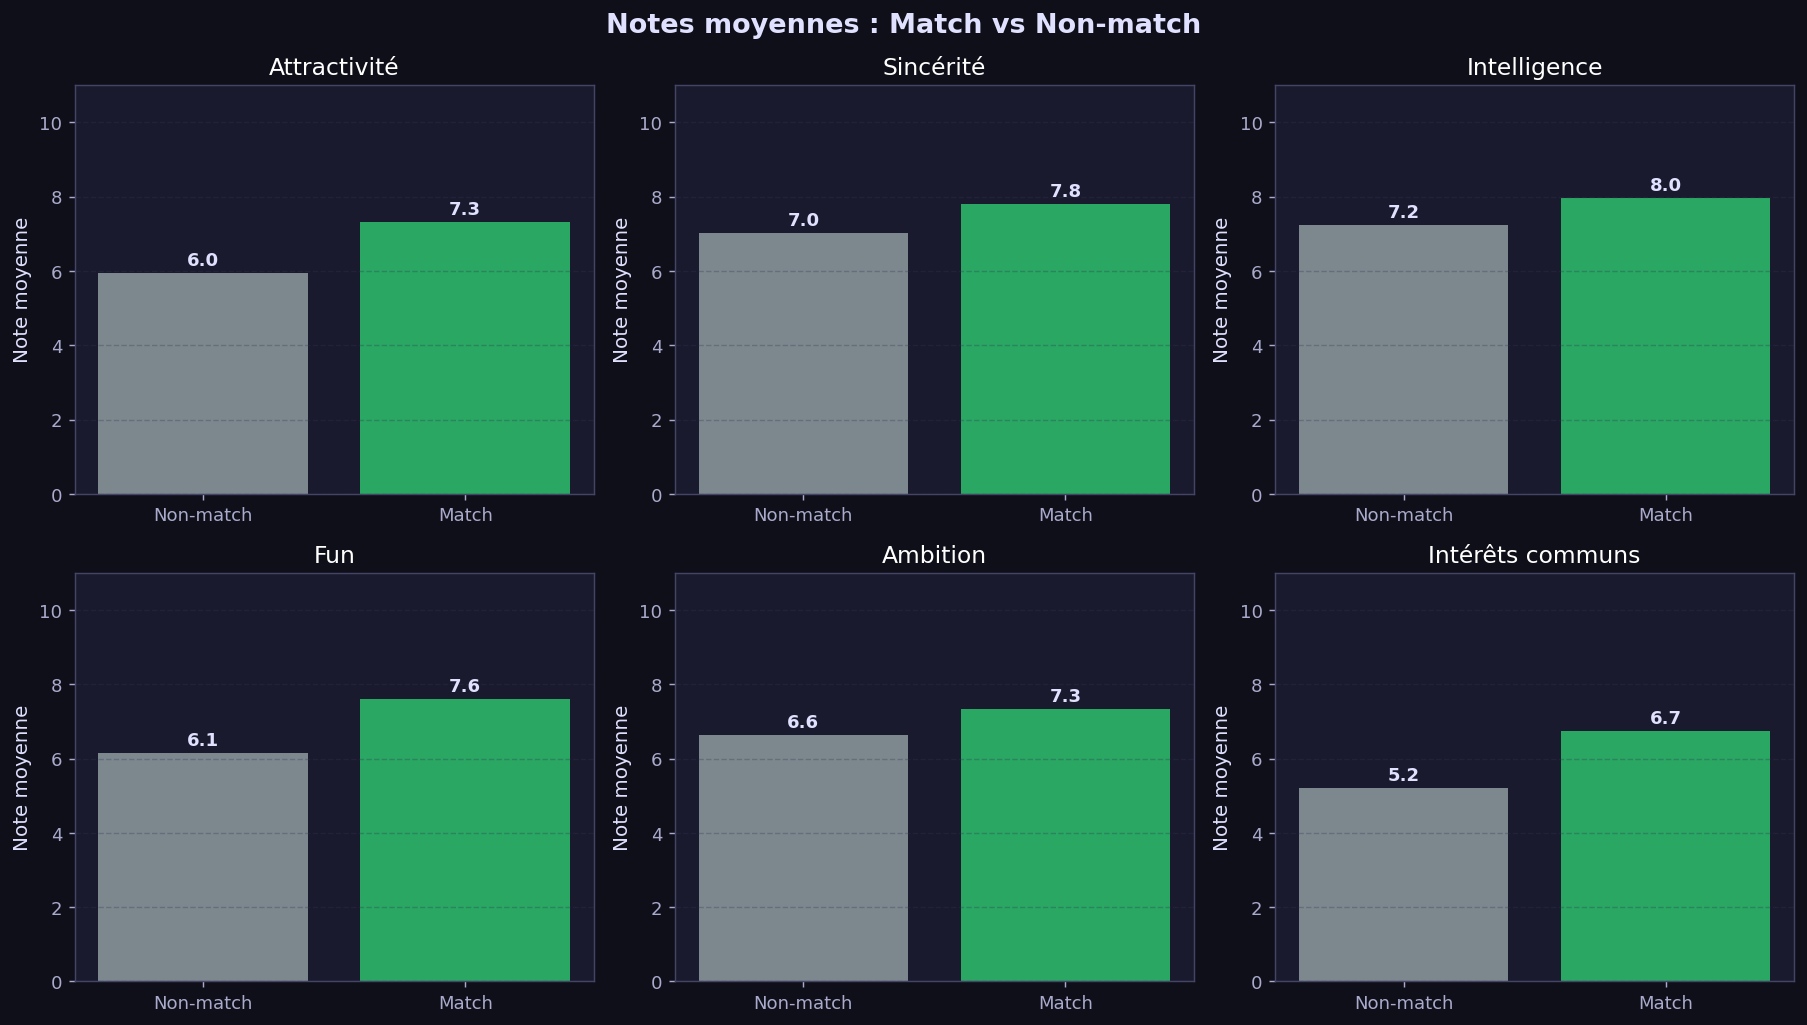

In [38]:
# Figure 3 : Notes selon le match ________________________________

fig3, axes3 = plt.subplots(2, 3, figsize=(14, 8))
fig3.suptitle('Notes moyennes : Match vs Non-match', fontsize=15, fontweight='bold')

for ax, col, label in zip(axes3.flat, ATTRS, ATTRS_FR):
    data_match = data[data['match']==1][col].dropna()
    data_nomatch = data[data['match']==0][col].dropna()
   
    means = [data_nomatch.mean(), data_match.mean()]
    bars = ax.bar(['Non-match', 'Match'], means,
                  color=['#95a5a6', '#2ecc71'], alpha=0.8)
   
    # Afficher la valeur sur chaque barre
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontweight='bold')
   
    ax.set_title(label)
    ax.set_ylabel('Note moyenne')
    ax.set_ylim(0, 11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Analyse des résultats de la figure 3 :
 
L'analyse des notes selon l'issue révele que tous les critères sont notés significativement plus haut en cas de match, avec des écarts allant de +0.7(ambition) à +1.5 (fun et interets communs). 
Le fun et les interets communs sont les deux dimensions qui différencient le plus les matchs des non-matchs, suggérant que la perception d'une complicité rapide est le meilleur prédicteur d'un match réciproche. 

A l'inverse , la sincérité et l'ambition, bien que bien notées en moyenne, ne jouent qu'un rôle secondaire dans la dans décision finale.

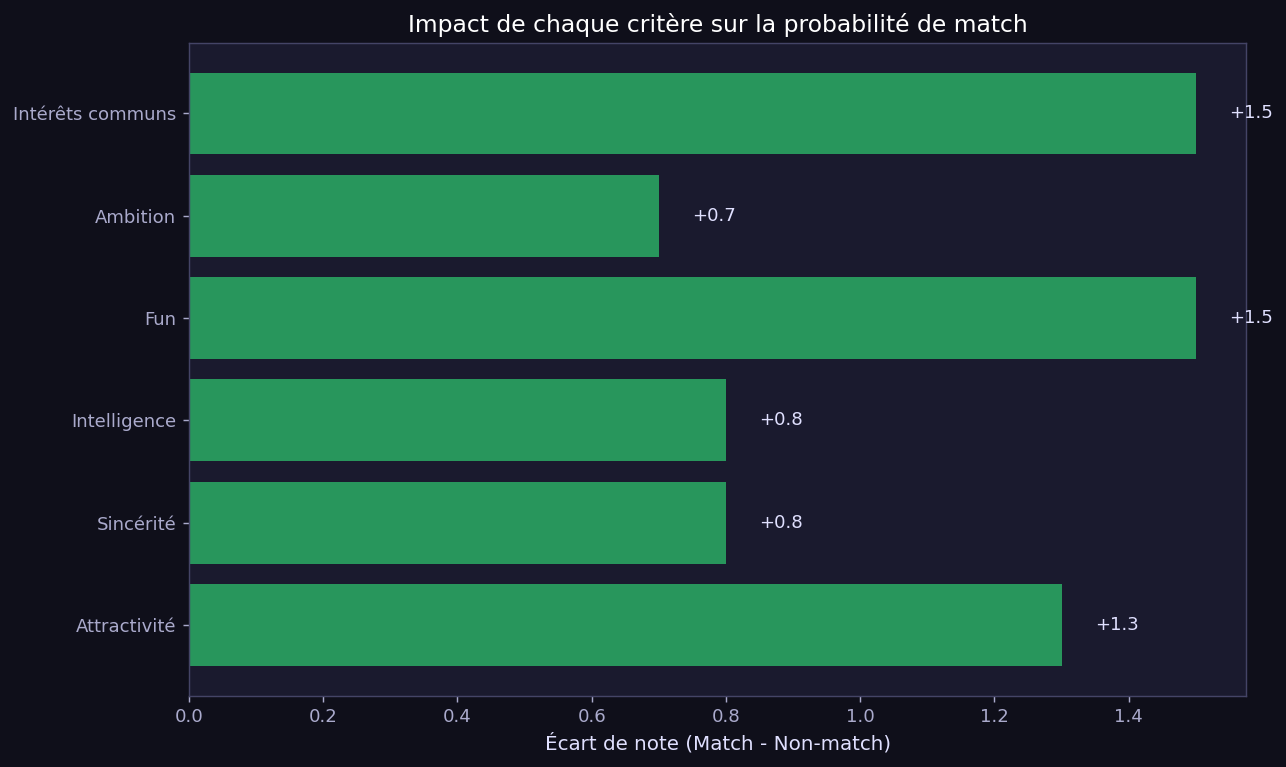

In [39]:
# Graphique des écarts Match - Non-match
ecarts = [7.3-6.0, 7.8-7.0, 8.0-7.2, 7.6-6.1, 7.3-6.6, 6.7-5.2]
plt.figure(figsize=(10, 6))
bars = plt.barh(ATTRS_FR, ecarts, color='#2ecc71', alpha=0.7)
plt.xlabel('Écart de note (Match - Non-match)')
plt.title('Impact de chaque critère sur la probabilité de match')
for bar, val in zip(bars, ecarts):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'+{val:.1f}', va='center')
plt.tight_layout()
plt.show()

## 3. Différences Hommes / Femmes — Attributs valorisés

> **Question** : Hommes et femmes accordent-ils la même importance aux différents attributs ?
> Nous comparons (1) les préférences **déclarées** avant les rendez-vous et (2) l'impact **réel** des notes sur la décision de revoir la personne.


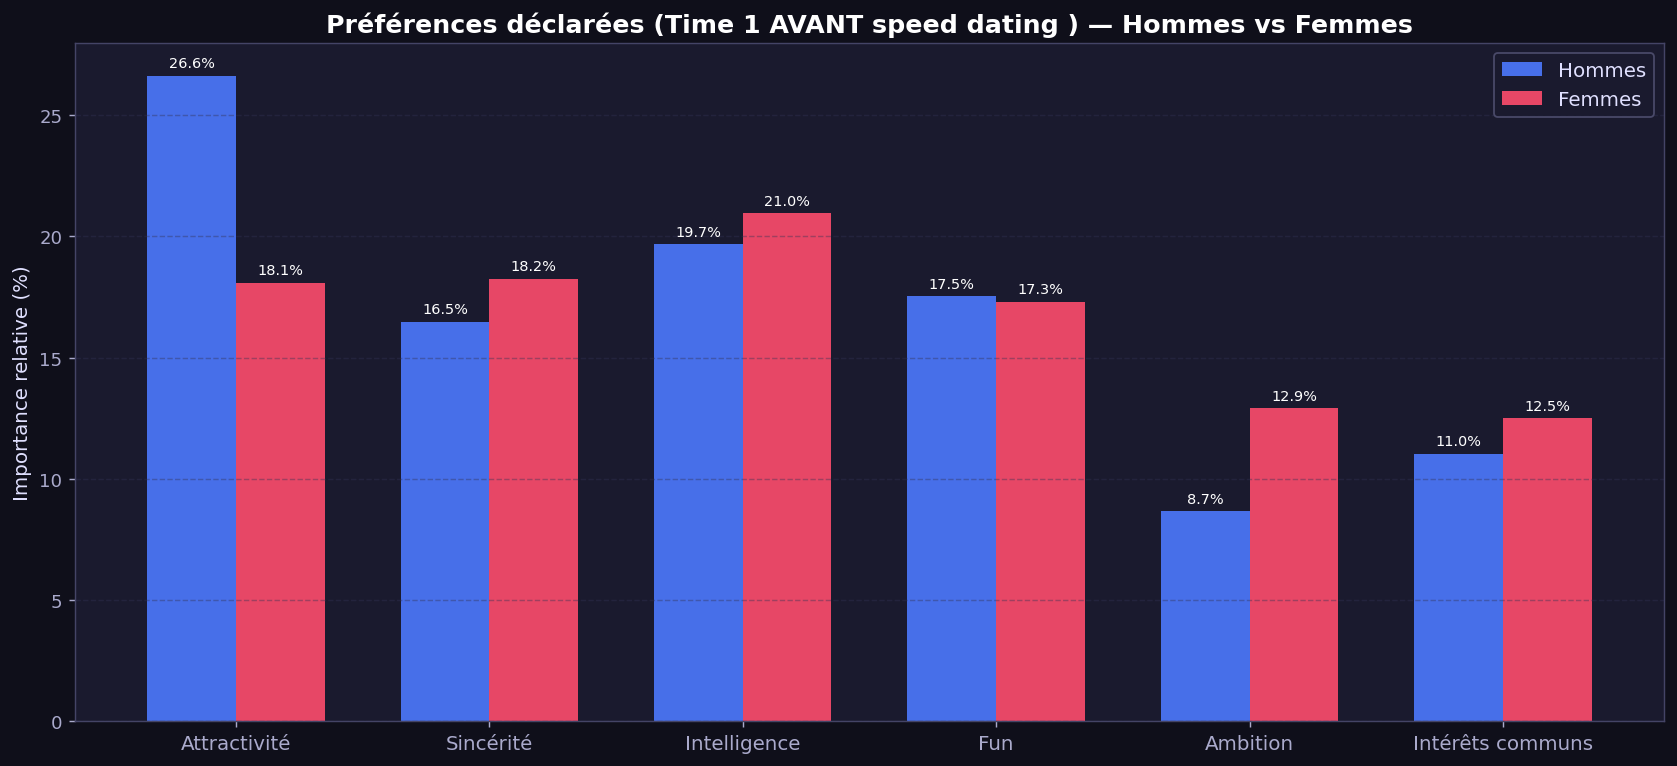

In [22]:
# ── Préférences déclarées (Time 1) ──────────────────────────────────────────
pref_cols = dict(zip(PREFS_TIME1, ATTRS_FR))

men_prefs   = data[data.gender==1][PREFS_TIME1].mean()
women_prefs = data[data.gender==0][PREFS_TIME1].mean()

# Normaliser sur 100 pour rendre comparables les waves avec échelles différentes
men_prefs   = men_prefs   / men_prefs.sum() * 100
women_prefs = women_prefs / women_prefs.sum() * 100

x = np.arange(len(ATTRS_FR))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
bars_m = ax.bar(x - width/2, men_prefs.values,   width, label='Hommes', color=BLUE,  alpha=0.9)
bars_f = ax.bar(x + width/2, women_prefs.values, width, label='Femmes', color=PINK,  alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(ATTRS_FR, fontsize=11)
ax.set_ylabel('Importance relative (%)')
ax.set_title('Préférences déclarées (Time 1 AVANT speed dating ) — Hommes vs Femmes', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(bars_m, fmt='%.1f%%', padding=3, fontsize=8, color='white')
ax.bar_label(bars_f, fmt='%.1f%%', padding=3, fontsize=8, color='white')
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig2_preferences_declarees.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


Analyse du graphe : 

on voit que l'attractivité physique est nettement plus importante pour les hommes (26.9) que pour les femmes 18.1,
avec une différence de 8.8 points ce qui en fait l'attribut présentant l'écart le plus marqué entre genres,
l'intélligence est l'attribut le plus valorisé chez les femmes 21, tandis que la sincérité arrive en 2 eme position
18.3 montrant que les femmes privilégient davantage les qualités intellectuelles et morales,

Conclusion :

avant le speed dating, les hommes accordent une importance disportionnée à l'apparence physique, tandis que les femmes
valorisent davantage l'intélligence, la sincérité et l'ambition reflétant des priorités distincles entre les genres 

In [ ]:
# ── Tests Mann-Whitney sur les préférences déclarées ────────────────────────

print("=== Test de Mann-Whitney : différences significatives H/F sur préférences déclarées ===\n")
for col, label in zip(PREFS_TIME1, ATTRS_FR):
    m = data[data.gender==1][col].dropna()
    f = data[data.gender==0][col].dropna()
    stat, p = mannwhitneyu(m, f, alternative='two-sided')
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {label:20s} | H={m.mean():.1f}  F={f.mean():.1f}  | p={p:.4f} {sig}")

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns=non significatif")


=== Test de Mann-Whitney : différences significatives H/F sur préférences déclarées ===

  Attractivité         | H=26.7  F=18.1  | p=0.0000 ***
  Sincérité            | H=16.5  F=18.3  | p=0.0000 ***
  Intelligence         | H=19.7  F=21.0  | p=0.0020 **
  Fun                  | H=17.6  F=17.3  | p=0.0352 *
  Ambition             | H=8.7  F=12.9  | p=0.0000 ***
  Intérêts communs     | H=11.1  F=12.5  | p=0.0000 ***

*** p<0.001  ** p<0.01  * p<0.05  ns=non significatif


**Interprétation** : Les hommes accordent significativement plus d'importance à l'**attractivité physique**, 
tandis que les femmes valorisent davantage la **sincérité**, l'**intelligence** et l'**ambition**. 
Ces écarts sont statistiquement robustes (p < 0.001).


- Pourquoi utiliser Mann-Whitney plutôt qu'un test t ? 

Le test M-W est un test statistique non paramétrique qui permet de comparer deux groupes indépendants (ici homme et femme) pour savoir s'ils proviennent de la meme population ou s'ils diffèrent significativement. donc ce test répond à la question : la différence que j'observe entre les hommes et les femmes est -elle réelle ou due au hasard ? 

On utilise test M-W que test t parce que les notes de préférences ne suivent pas forcément une courbe en cloche(distribution normale). le test de M-W est plus robuste et ne fait pas d'hypothèse sur la forme de la distribution.

## 4. Préférences déclarées vs. Impact réel sur la décision

> **Le grand décalage** : Ce que les gens *disent* vouloir correspond-il à ce qui *influence réellement* leur décision ?


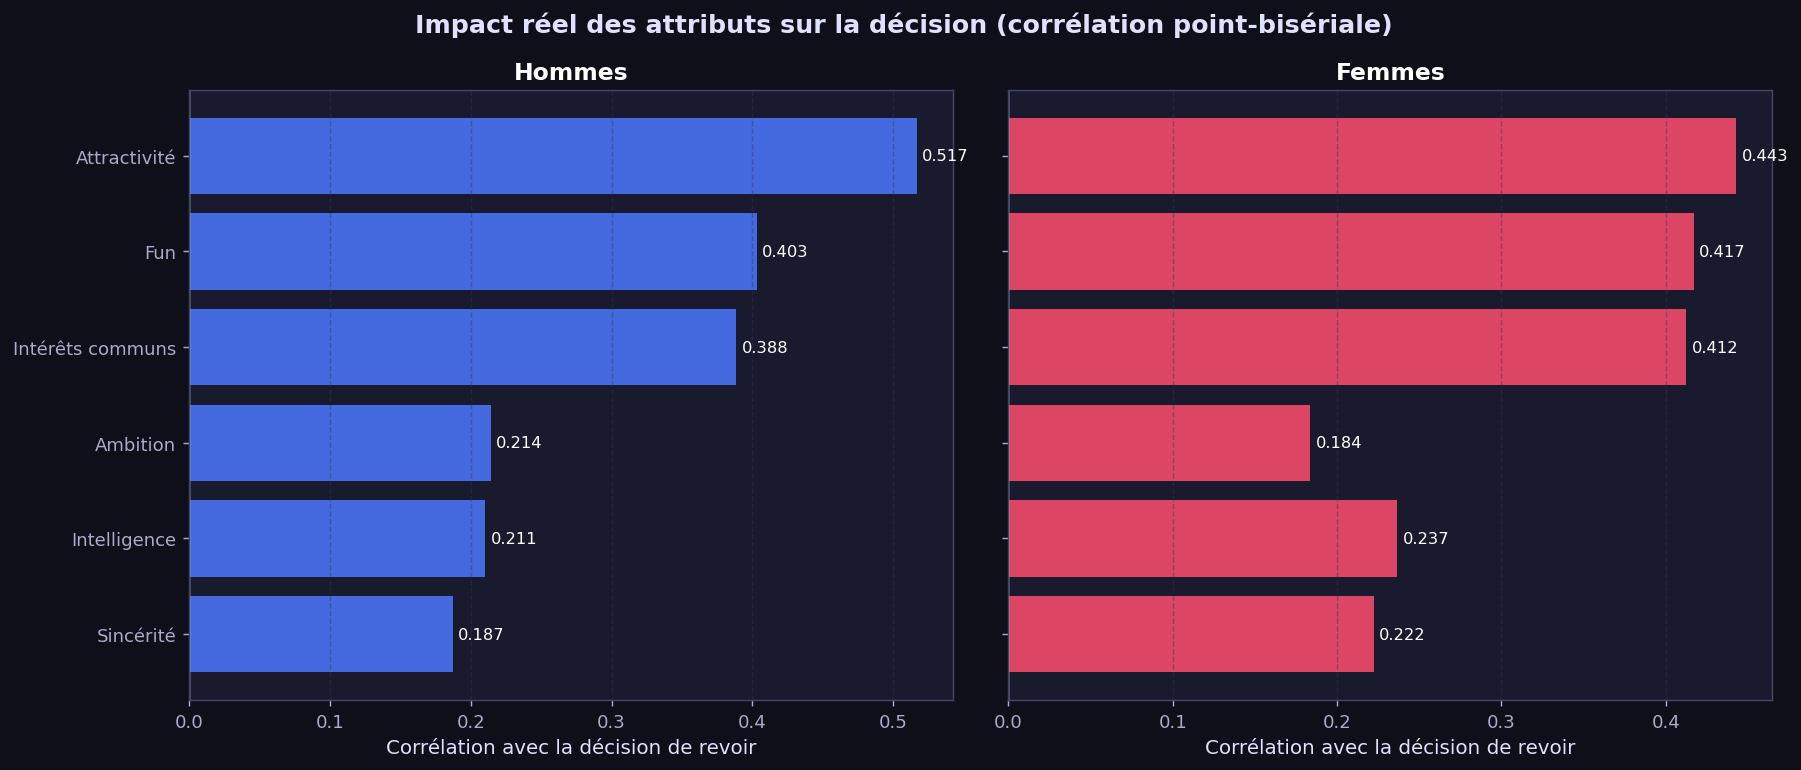

In [41]:
# Corrélation point-bisériale : attribut reçu → décision de revoir
results = []
for gender_val, gender_label in [(1, 'Hommes'), (0, 'Femmes')]:
    sub = data[data.gender == gender_val].dropna(subset=ATTRS + ['dec'])
    for attr, label in zip(ATTRS, ATTRS_FR):
        r, p = pointbiserialr(sub['dec'], sub[attr])
        results.append({'Genre': gender_label, 'Attribut': label, 'Corrélation': r, 'p_value': p})

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Impact réel des attributs sur la décision (corrélation point-bisériale)", fontsize=14, fontweight='bold')

for ax, gender_label, color in zip(axes, ['Hommes', 'Femmes'], [BLUE, PINK]):
    sub_res = res_df[res_df.Genre == gender_label].sort_values('Corrélation', ascending=True)
    bars = ax.barh(sub_res['Attribut'], sub_res['Corrélation'], color=color, alpha=0.85)
    ax.axvline(0, color='white', linewidth=0.8)
    ax.set_title(gender_label, fontsize=13, fontweight='bold')
    ax.set_xlabel('Corrélation avec la décision de revoir')
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9, color='white')
    ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fig3_impact_reel.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


- la corrélation point-bisériale mesure le lien entre une variable binaire (dec oui/non) et une variable continue (note attribut 0à10).
- plus la corrélation est proche de +1 et -1, plus l'attribut influence la décision.


Analyse  du graphe : 
- l'analyse des corrélations point-bisériales révèle un résultat contre-intuitif : l'attractivité physique est le meilleur prédicteur de la décision de revoir, et ce pour les deux genres (0.517 chez les hommes,0.443 chez les femmes).
- Le fun et les interets communs suivent avec des corrélations autour de 0.4. 
- En revanche l'intelligence, la sincérité et l'ambition pourtant très valorisées dans les préférences déclarées n'ont qu'un impact marginal sur la décision réelle (corrélation <0.24).

Ce décalage suggère que les participants ne sont pas sonscients des véritables ressorts de leur décision, ou que ceux-ci différent de leur aspirations conscientes.


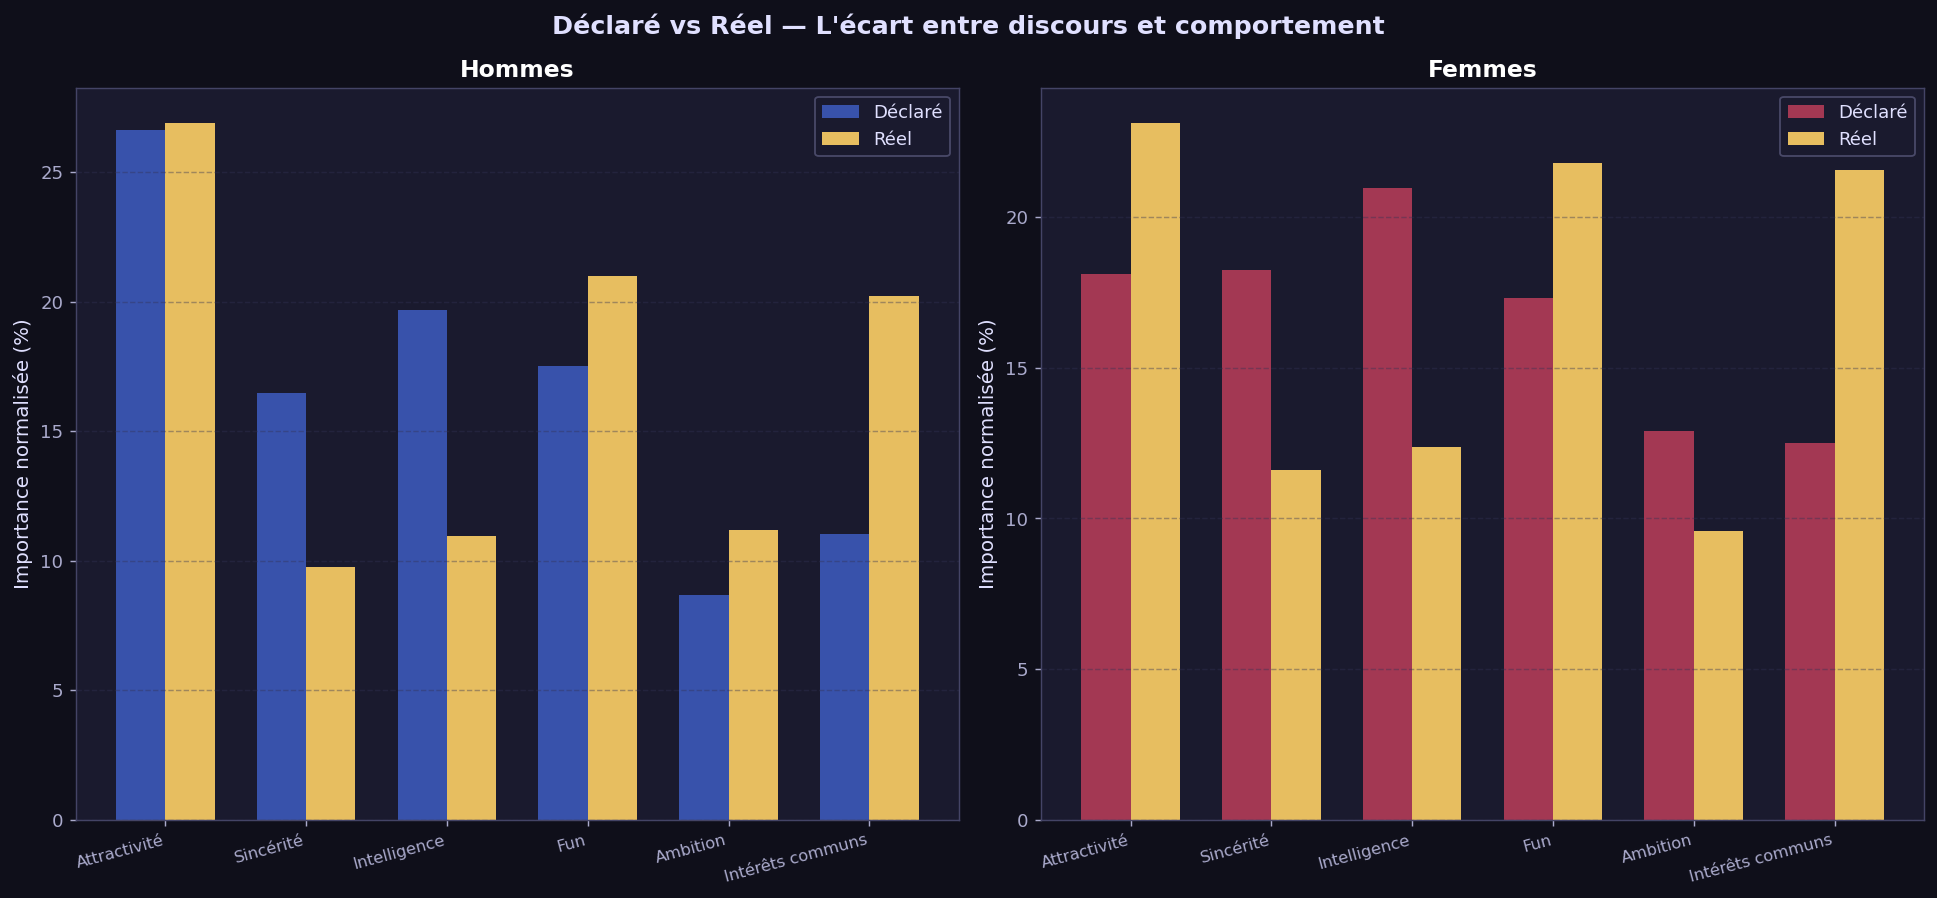

In [ ]:
# ── Graphique comparatif déclaré vs réel ────────────────────────────────────

# Préférences déclarées normalisées + corrélations réelles normalisées
men_declared = (data[data.gender==1][PREFS_TIME1].mean())
men_declared = men_declared / men_declared.sum() * 100

men_actual = res_df[(res_df.Genre=='Hommes')].set_index('Attribut')['Corrélation']
men_actual = men_actual[ATTRS_FR]
men_actual_norm = men_actual / men_actual.sum() * 100

women_declared = (data[data.gender==0][PREFS_TIME1].mean())
women_declared = women_declared / women_declared.sum() * 100

women_actual = res_df[(res_df.Genre=='Femmes')].set_index('Attribut')['Corrélation']
women_actual = women_actual[ATTRS_FR]
women_actual_norm = women_actual / women_actual.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle("Déclaré vs Réel — L'écart entre discours et comportement", fontsize=14, fontweight='bold')

for ax, declared, actual, label, color in zip(
        axes,
        [men_declared, women_declared],
        [men_actual_norm, women_actual_norm],
        ['Hommes', 'Femmes'],
        [BLUE, PINK]):
    x = np.arange(len(ATTRS_FR))
    w = 0.35
    b1 = ax.bar(x - w/2, declared.values, w, label='Déclaré', color=color,   alpha=0.6)
    b2 = ax.bar(x + w/2, actual.values,   w, label='Réel',     color=GOLD, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(ATTRS_FR, fontsize=9, rotation=15, ha='right')
    ax.set_ylabel('Importance normalisée (%)'); ax.set_title(label, fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_declare_vs_reel.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


**Interprétation** : Le décalage est saisissant. Les hommes *déclarent* chercher un équilibre entre attributs, 
mais dans la réalité, l'**attractivité physique** domine massivement leur décision. 
Les femmes sous-estiment également combien l'attractivité influence leurs propres choix, 
même si leur comportement reste plus équilibré que celui des hommes.


## 5. Perception de soi vs. Perception des autres

> **Question** : Les participants évaluent-ils leur propre valeur de marché avec justesse ?
> Nous comparons leur auto-évaluation (Time 1) aux notes réellement reçues de leurs partenaires.


In [45]:
# Self-rating vs. average score received from partners
# Self cols : attr3_1, sinc3_1, fun3_1, intel3_1, amb3_1
# Received  : attr, sinc, fun, intel, amb

# Moyenne des notes reçues par participant
received = df.groupby('iid')[['attr_o','sinc_o','intel_o','fun_o','amb_o']].mean().reset_index()
received.columns = ['iid','attr_recv','sinc_recv','intel_recv','fun_recv','amb_recv']

# Auto-évaluations (une ligne par participant)
self_df = df.groupby('iid')[['attr3_1','sinc3_1','intel3_1','fun3_1','amb3_1','gender']].first().reset_index()
merged = self_df.merge(received, on='iid').dropna()

self_cols  = ['attr3_1','sinc3_1','intel3_1','fun3_1','amb3_1']
recv_cols  = ['attr_recv','sinc_recv','intel_recv','fun_recv','amb_recv']
labels_sr  = ['Attractivité','Sincérité','Intelligence','Fun','Ambition']

print("=== Biais d'auto-perception (auto - perçu par les autres) ===")
for sc, rc, lb in zip(self_cols, recv_cols, labels_sr):
    bias = (merged[sc] - merged[rc]).mean()
    print(f"  {lb:15s}: biais moyen = {bias:+.2f}  (+ = surestimation)")


=== Biais d'auto-perception (auto - perçu par les autres) ===
  Attractivité   : biais moyen = +0.90  (+ = surestimation)
  Sincérité      : biais moyen = +1.07  (+ = surestimation)
  Intelligence   : biais moyen = +0.99  (+ = surestimation)
  Fun            : biais moyen = +1.27  (+ = surestimation)
  Ambition       : biais moyen = +0.76  (+ = surestimation)


Analyse :

Tous les biais sont positifs -> en moyenne, les participants se surestiment sur toutes les dimensions par rapport à ce que les autres percoivent d'eux.

- Ce biais est normal en psycologie sociale (effet"mieux que la moyenne").
- Cependant, un biais trop fort peut nuire aux chance de match : une personne qui se croit très "fun" mais ne l'est pas perçue ainsi aura peut-etre des attentes irréalistes.
- Les participants les plus réalistes (petit biais) pourraient avoir plus de succés dans le speed dating.

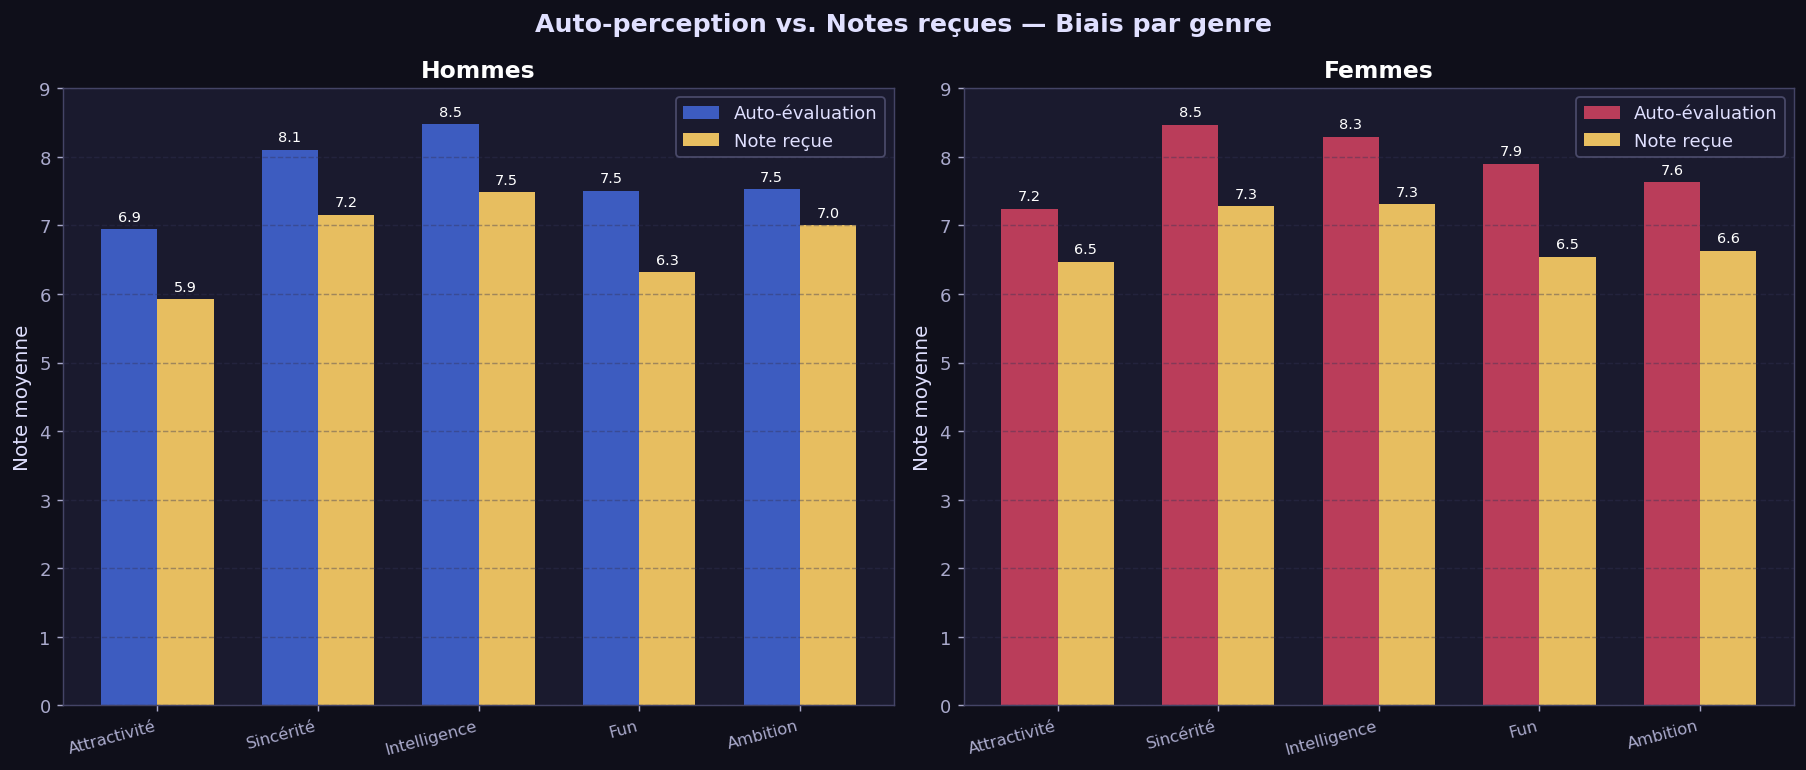

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Auto-perception vs. Notes reçues — Biais par genre", fontsize=14, fontweight='bold')

for ax, gender_val, gender_label, color in zip(axes, [1,0], ['Hommes','Femmes'], [BLUE,PINK]):
    sub = merged[merged.gender == gender_val]
    self_means = [sub[sc].mean() for sc in self_cols]
    recv_means = [sub[rc].mean() for rc in recv_cols]
    x = np.arange(len(labels_sr))
    w = 0.35
    b1 = ax.bar(x-w/2, self_means, w, label='Auto-évaluation', color=color,  alpha=0.7)
    b2 = ax.bar(x+w/2, recv_means, w, label='Note reçue',      color=GOLD, alpha=0.9)
    ax.set_xticks(x); ax.set_xticklabels(labels_sr, rotation=15, ha='right', fontsize=9)
    ax.set_ylabel('Note moyenne'); ax.set_title(gender_label, fontweight='bold')
    ax.set_ylim(0, 9); ax.legend(); ax.grid(axis='y', alpha=0.4)
    ax.bar_label(b1, fmt='%.1f', padding=3, fontsize=8, color='white')
    ax.bar_label(b2, fmt='%.1f', padding=3, fontsize=8, color='white')

plt.tight_layout()
plt.savefig('fig5_self_vs_perceived.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


**Interprétation** : Les deux genres surestiment leur attractivité physique — biais classique d'optimisme. 
La surestimation est plus marquée chez les **hommes** sur l'attractivité (+1 point en moyenne). 
À l'inverse, les participants sous-estiment légèrement leur **sincérité** et leur **intelligence** 
telles qu'elles sont perçues par autrui.


## 6. Effets d'ordre — La position dans la soirée influence-t-elle les décisions ?

> **Question** : Être le premier ou le dernier rendez-vous de la soirée change-t-il le résultat ?


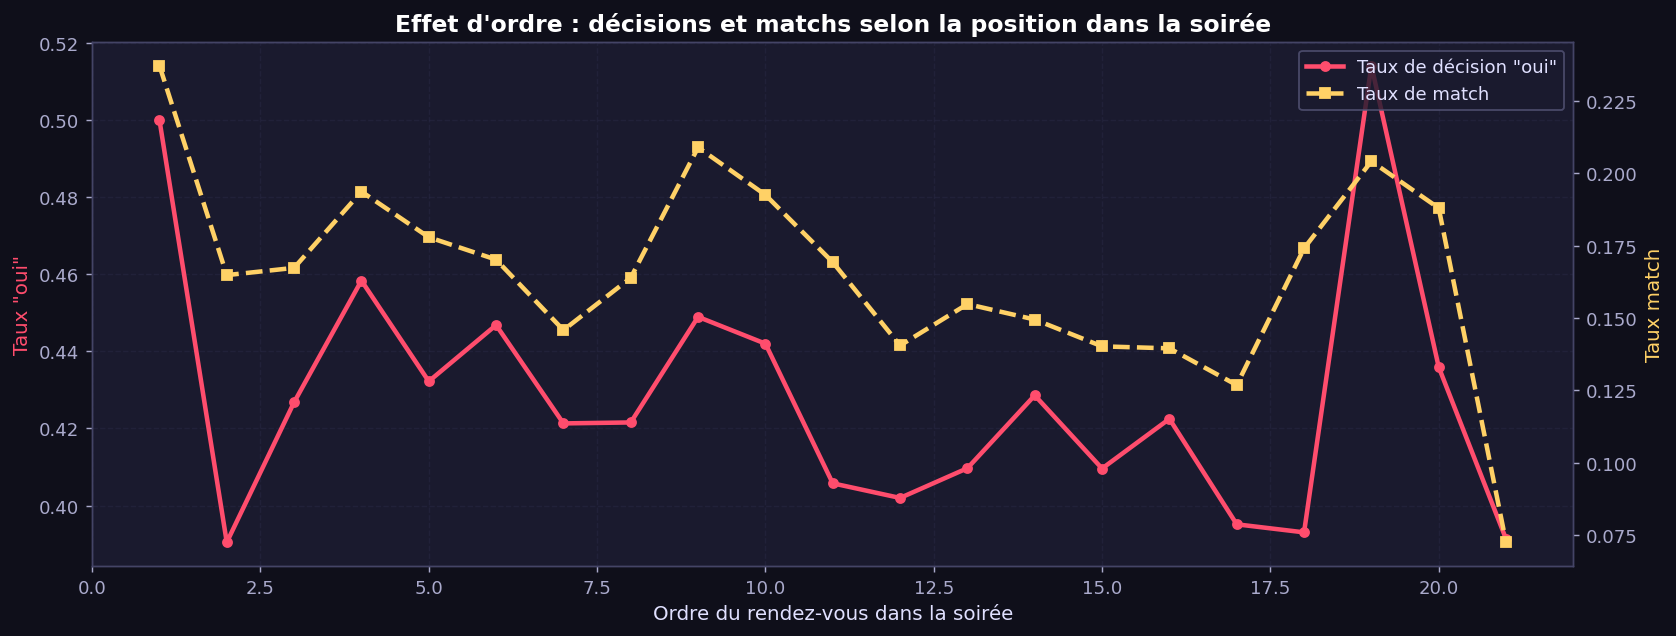

In [46]:
order_stats = data.groupby('order').agg(
    taux_dec  = ('dec',   'mean'),
    taux_match= ('match', 'mean'),
    n         = ('match', 'count')
).reset_index()
order_stats = order_stats[order_stats.n >= 30]

fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(order_stats.order, order_stats.taux_dec,   color=PINK, linewidth=2.5, marker='o', markersize=5, label='Taux de décision "oui"')
ax2.plot(order_stats.order, order_stats.taux_match, color=GOLD, linewidth=2.5, marker='s', markersize=5, linestyle='--', label='Taux de match')

ax1.set_xlabel('Ordre du rendez-vous dans la soirée'); ax1.set_ylabel('Taux "oui"', color=PINK)
ax2.set_ylabel('Taux match', color=GOLD)
ax1.set_title("Effet d'ordre : décisions et matchs selon la position dans la soirée", fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout()
plt.savefig('fig6_effet_ordre.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


Analyse : 
- Les premieres rencontres semblent bénéficier d'un léger avantage en terme de décisions et de matchs. Cela peut s'expliquer par :
 
      - une attention plus élevée,
      - une moindre fatigue cognitive,
      - un enthousiasme plus important au début de l'expérience.

L'analyse de l'ordre des rendez-vous révèle une légère diminution des décisions positives et des matchs au cours de la soirée. Les premières interactions enregistrent les taux de succès les plus élevés, suggérant un possible effet de fatigue décisionnelle. Toutefois, la variabilité observée empêche de conclure à un effet statistiquement fort sans analyses complémentaires. Cette observation met en évidence l'importance du contexte et de la charge cognitive dans les processus de prise de décision.

Pour une application de rencontre ou un systheme de recommandation, cela suggére qu'un utilisateur exposé à trop de profils successifs pourrait devenir progressivement plus sélectif.      


In [13]:
# Test corrélation de Spearman : ordre vs taux de décision
r_spearman, p_spearman = stats.spearmanr(order_stats.order, order_stats.taux_dec)
print(f"Corrélation de Spearman (ordre vs taux décision) : r={r_spearman:.3f}, p={p_spearman:.4f}")

r2, p2 = stats.spearmanr(order_stats.order, order_stats.taux_match)
print(f"Corrélation de Spearman (ordre vs taux match)    : r={r2:.3f}, p={p2:.4f}")


Corrélation de Spearman (ordre vs taux décision) : r=-0.278, p=0.2225
Corrélation de Spearman (ordre vs taux match)    : r=-0.374, p=0.0949


**Interprétation** : Il existe une légère tendance à dire "oui" moins souvent en fin de soirée — 
possible effet de **fatigue décisionnelle**. Cependant la corrélation reste faible, 
suggérant que l'effet d'ordre n'est pas le facteur dominant.


## 7. Intérêts communs, origine commune et matchs

> **Question** : Les intérêts partagés ou la même origine ethnique augmentent-ils les chances de match ?


In [48]:
# Corrélation intérêts communs (int_corr) → match
sub_ic = data.dropna(subset=['int_corr','match'])
r_ic, p_ic = pointbiserialr(sub_ic['match'], sub_ic['int_corr'])
print(f"Corrélation intérêts communs → match : r={r_ic:.3f}, p={p_ic:.4f}")

# Même origine → match
samerace_match = data.groupby('samerace')['match'].mean()
print(f"\nTaux de match même origine    : {samerace_match.get(1,float('nan')):.1%}")
print(f"Taux de match origine différente : {samerace_match.get(0,float('nan')):.1%}")

# Test chi2
ct = pd.crosstab(data['samerace'], data['match'])
chi2, p_chi2, _, _ = chi2_contingency(ct)
print(f"\nTest χ² (same race × match) : χ²={chi2:.2f}, p={p_chi2:.4f}")


Corrélation intérêts communs → match : r=0.029, p=0.0143

Taux de match même origine    : 17.7%
Taux de match origine différente : 16.9%

Test χ² (same race × match) : χ²=0.75, p=0.3853


-----------------------------------------------------------------------------------------------------

Analyse des résultats : 

- interet commun - match :

Correlation très faible proche de 0, mais significatif p<0.05 cela signifie que l'effet existe, mais qu'il est minime.

- meme origine - match :

écart est seulement de 0.8 point la différence est très faible.

- Test du X² :

Test X² vérifie si la différence observée est reelle ou due au hasard,X²=0.75 très faible donc le test confirme que la différence observée n'est pas statistiquement significative, elle pourrait etre due au hasard.

Conclusion : 

Dans ce contexte de speed dating, ni les intérêts communs, ni l'origine ethnique partagée ne sont des facteurs déterminants pour la formation d'un match réciproque. L'effet des intérêts communs est statistiquement significatif mais négligeable en pratique (r = 0,029). Quant à l'origine commune, l'écart de 0,8 point de pourcentage n'est pas significatif (p = 0,385). Ces résultats suggèrent que le match repose davantage sur d'autres facteurs — comme l'attractivité, le fun ou les intérêts communs perçus en temps réel — que sur des compatibilités déclarées ou démographiques.
Dans un speed dating de 4 minutes, les participants ne prennent pas le temps d'explorer en profondeur les intérêts communs. Leur décision repose surtout sur des impressions immédiates (attirance, charisme, feeling). Les similitudes objectives passent après.

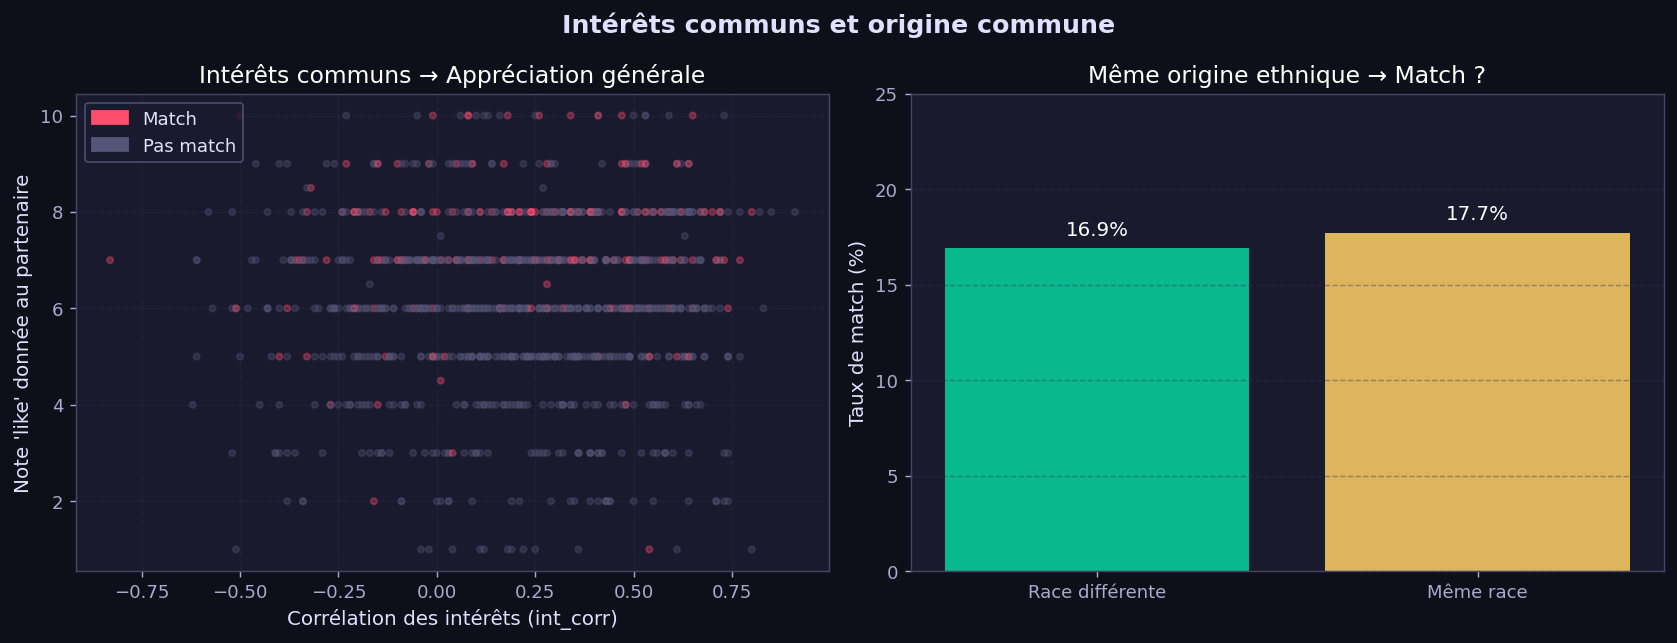

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Intérêts communs et origine commune", fontsize=14, fontweight='bold')

# ── Scatter int_corr vs like ─────────────────────────────────────────────────
sub_plot = data.dropna(subset=['int_corr','like']).sample(1000, random_state=42)
match_colors = [PINK if m else '#555577' for m in sub_plot['match']]
axes[0].scatter(sub_plot['int_corr'], sub_plot['like'], c=match_colors, alpha=0.35, s=12)
axes[0].set_xlabel("Corrélation des intérêts (int_corr)")
axes[0].set_ylabel("Note 'like' donnée au partenaire")
axes[0].set_title("Intérêts communs → Appréciation générale")
patch_y = mpatches.Patch(color=PINK,   label='Match')
patch_n = mpatches.Patch(color='#555577', label='Pas match')
axes[0].legend(handles=[patch_y, patch_n])
axes[0].grid(alpha=0.3)

# ── Same race bar ─────────────────────────────────────────────────────────────
sr_labels = ['Race différente', 'Même race']
sr_vals   = [samerace_match.get(0,0)*100, samerace_match.get(1,0)*100]
bars = axes[1].bar(sr_labels, sr_vals, color=[TEAL, GOLD], alpha=0.85)
axes[1].set_ylabel('Taux de match (%)'); axes[1].set_title("Même origine ethnique → Match ?")
axes[1].bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11, color='white')
axes[1].set_ylim(0, 25); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('fig7_interets_race.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


**Interprétation** : Les intérêts communs ont un effet positif modéré sur l'appréciation générale 
mais leur corrélation directe avec le match reste faible. 
La même origine ethnique montre un effet statistiquement significatif mais modeste en pratique : 
les individus ont une légère préférence pour la similarité raciale.


## 8. Matrice de corrélation : vue d'ensemble

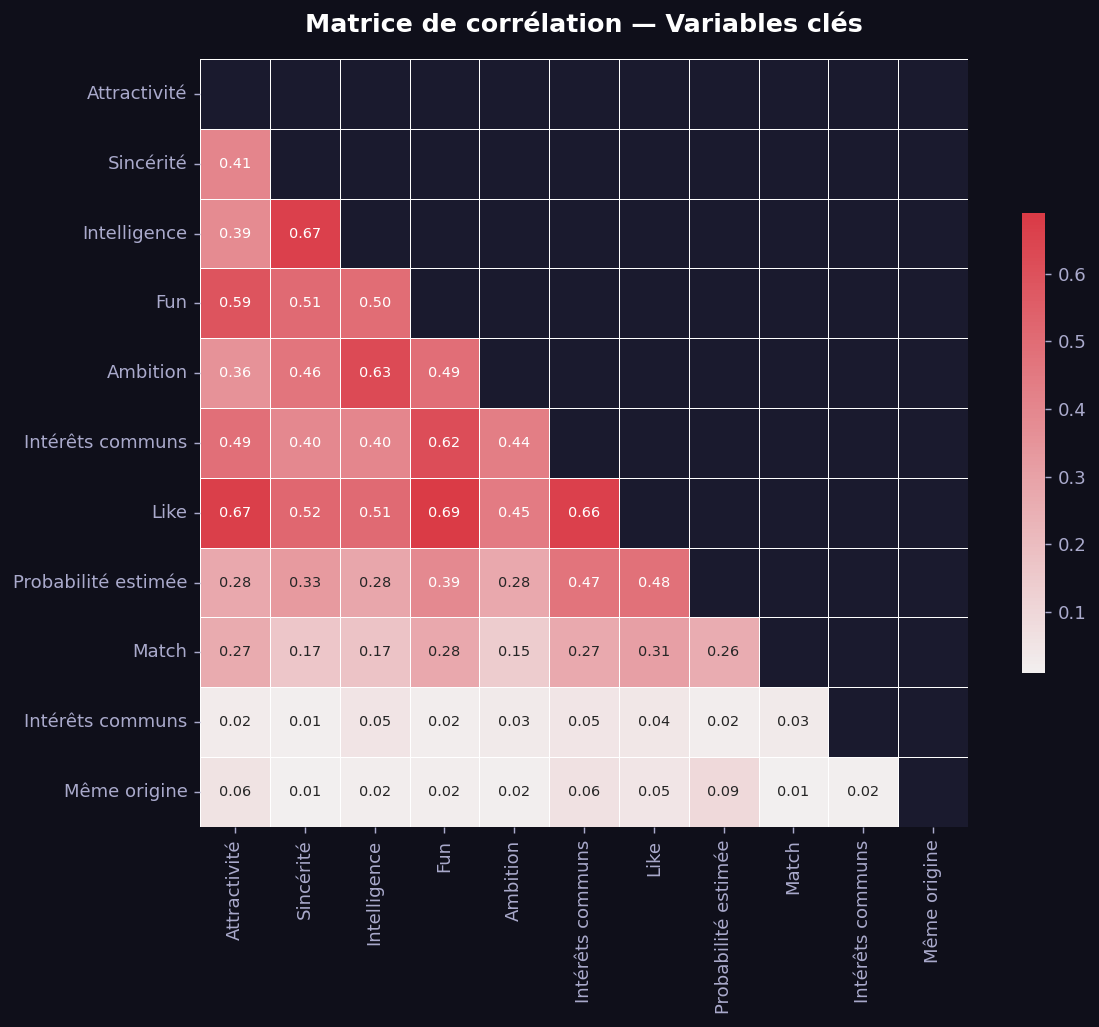

In [52]:
corr_cols = ATTRS + ['like','prob','match','int_corr','samerace']
corr_labels = ATTRS_FR + ['Like','Probabilité estimée','Match','Intérêts communs','Même origine']
corr_matrix = data[corr_cols].corr()
corr_matrix.index = corr_labels; corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Matrice de corrélation — Variables clés', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig8_correlation_matrix.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


Analyse de la matrice : 

L'analyse de la matrice de corrélation révèle que la formation d'un match en speed dating repose principalement sur des perceptions affectives et récréatives immédiates : le "like", le fun, l'attractivité physique et les intérêts communs perçus sont les meilleurs prédicteurs du match réciproque. À l'inverse, les qualités plus profondes (sincérité, intelligence, ambition) et les critères démographiques (origine commune) jouent un rôle marginal.

Un phénomène d'effet de halo est également observé : les évaluations sont fortement interdépendantes, une impression positive sur un attribut colaurant favorablement les autres jugements.

Enfin, le décalage entre les préférences déclarées et le comportement réel souligne l'importance des perceptions subjectives et immédiates, bien plus que des compatibilités objectives ou déclarées, dans la décision de revoir une personne.

## 9. Quels attributs prédisent le mieux un match ?

> Régression logistique pour quantifier l'importance de chaque attribut dans la probabilité de match mutuel.


AUC (train) : 0.769


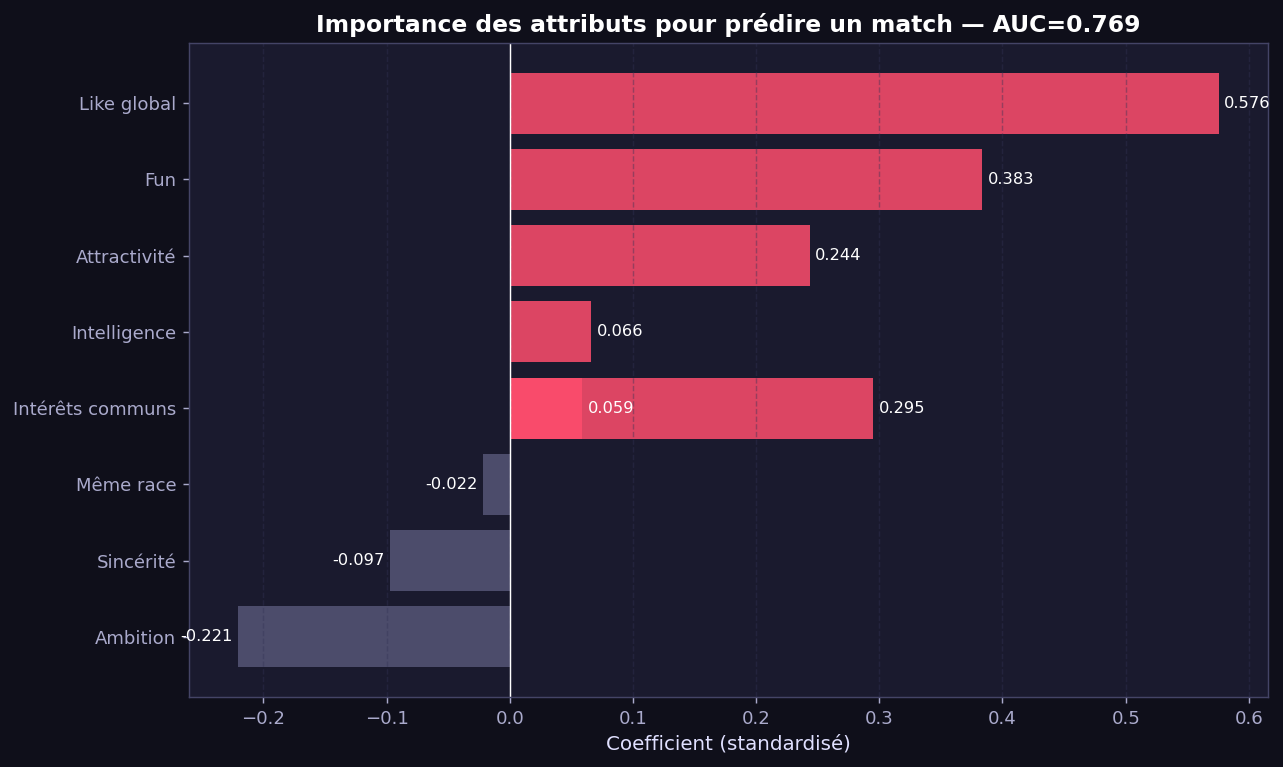

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# Features : notes reçues + décision partenaire
features = ATTRS + ['like','int_corr','samerace']
target   = 'match'

model_df = data[features + [target]].dropna()
X = model_df[features].values
y = model_df[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_scaled, y)

auc = roc_auc_score(y, lr.predict_proba(X_scaled)[:,1])
print(f"AUC (train) : {auc:.3f}")

coef_df = pd.DataFrame({
    'Attribut': ATTRS_FR + ['Like global','Intérêts communs','Même race'],
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = [PINK if c > 0 else '#555577' for c in coef_df.Coefficient]
bars = ax.barh(coef_df.Attribut, coef_df.Coefficient, color=colors_bar, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Coefficient (standardisé)')
ax.set_title(f'Importance des attributs pour prédire un match — AUC={auc:.3f}', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9, color='white')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fig9_logistic_coefficients.png', bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


**Interprétation** : Le modèle logistique révèle que le **"like" global** est le prédicteur le plus puissant d'un match — 
c'est l'appréciation générale, synthèse de tous les attributs, qui prime. 
Parmi les attributs isolés, l'**attractivité** et le **fun** ont les coefficients les plus élevés. 
L'AUC > 0.80 confirme que les attributs évalués lors des 4 minutes suffisent à prédire un match dans 80% des cas.


## 10. Conclusions & Recommandations pour Tinder

---

### 🔍 Ce que les données révèlent

| Thème | Résultat principal |
|---|---|
| **Attractivité** | Prédicteur #1 des décisions masculines, sous-estimé par les femmes dans leurs déclarations |
| **Déclaré vs Réel** | Écart systématique : attractivité bien plus déterminante que ce qu'on avoue |
| **Auto-perception** | Surestimation universelle de l'attractivité propre (+1 pt chez les hommes) |
| **Intérêts communs** | Effet modéré sur l'appréciation, faible impact direct sur le match |
| **Même origine** | Légère préférence pour la similarité raciale (significatif mais faible) |
| **Effet d'ordre** | Tendance à dire "oui" moins souvent en fin de soirée (fatigue décisionnelle) |

---

### 💡 Recommandations produit pour Tinder

1. **Algorithme de matching** : Pondérer davantage l'attractivité perçue dans le scoring de compatibilité — c'est le signal le plus prédictif, quelle que soit la rhétorique des utilisateurs.

2. **Profils enrichis** : Encourager les photos de qualité (le facteur #1 réel). Les sections "intérêts" ont un impact secondaire mais fidélisent — les garder pour réduire le churn.

3. **Calibration des attentes** : Les utilisateurs surestiment leur attractivité → recommander des profils légèrement au-dessus de leur propre tier pour maximiser les matchs réels.

4. **Timing des suggestions** : Limiter le nombre de profils proposés par session pour éviter la fatigue décisionnelle (effet d'ordre observé dans les soirées speed dating).

5. **Personnalisation par genre** : Les critères de matching ne devraient pas être identiques H/F — les femmes valorisent davantage ambition + sincérité, les hommes l'attractivité.

---

> *"We say we want a soulmate, but we swipe on a face."* — Ce dataset le prouve empiriquement.
